In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("hw1-task2.ipynb")

# Homework 1 Task 2: Simple Linear Regression 
## Do eDNA and Traditional Sampling Detect the Same Number of Fish Species?


---

### Background

Environmental DNA (eDNA) sampling detects species by collecting and sequencing genetic material shed into the water — no nets or electrofishing required. Traditional methods require direct capture or observation. This dataset, the same as used in Task 1, compiles results from **68 freshwater lake surveys** across multiple published studies, comparing species detected by each method.

Your goal is to investigate whether **eDNA-based species richness** (`dna_richness`) can predict **traditional species richness** (`trad_richness`) — the number of species found by conventional gear. This is a question for conservation monitoring: if the two methods broadly agree, eDNA could replace expensive field surveys.

You will build and evaluate a simple linear regression model from scratch using NumPy, and then verify your results with `sklearn` and `statsmodels`.

---


The dataset has the following key columns:

| Column | Description |
|---|---|
| `author` | First author of the primary study |
| `area_ha` | Lake area (hectares) |
| `dna_richness` | Number of fish species detected by eDNA |
| `trad_richness` | Number of fish species detected by conventional surveys |
| `dna_only` | Number of species found **only** by eDNA |
| `trad_only` | Number of species found **only** by conventional surveys |
| `shared` | Number of species found by **both** methods |
| `union` | Total unique species (`dna_only + trad_only + shared`) |
| `marker_cat` | Whether single or multiple genetic markers were used (single vs. multiple eDNA markers) |
| `gear_cat` | Whether single or multiple conventional survey gear types were used (single vs. multiple) |
| `total_vol_liter` | Total volume of water sampled (litres) |

### Setup: Load libraries and read in data


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv('lakes_data.csv') 
df.head()

,author,year_pub,area_ha,dna_richness,trad_richness,dna_only,trad_only,shared,union,marker_count,locus,marker_cat,gear_cat,match_effort,field_reps,rep_vol_liter,total_vol_liter
0,Civade,2016,545.0,14,18,1,5,13,19,1,12s,single,single,yes,3,45.00,135.00
1,Doble,2020,3290000.0,92,62,41,11,51,103,4,12s_16s,multiple,single,yes,21,10.00,210.00
2,Evans,2017,2.0,15,10,5,0,10,15,3,12s_16s_cytb,multiple,multiple,yes,31,0.25,7.75
3,Fujii,2019,9.0,0,7,0,7,0,7,1,12s,single,multiple,no,1,1.00,1.00
4,Fujii,2019,5.0,2,8,0,6,2,8,1,12s,single,multiple,no,1,1.00,1.00


<!-- BEGIN QUESTION -->

---
## Step 1: Visualise the Relationship

Create an exploratory data visualization exploring the relationship between `dna_richness` and `trad_richness`. 

<Axes: title={'center': 'Traditional Richness vs DNA Richness'}, xlabel='DNA Richness', ylabel='Traditional Richness'>

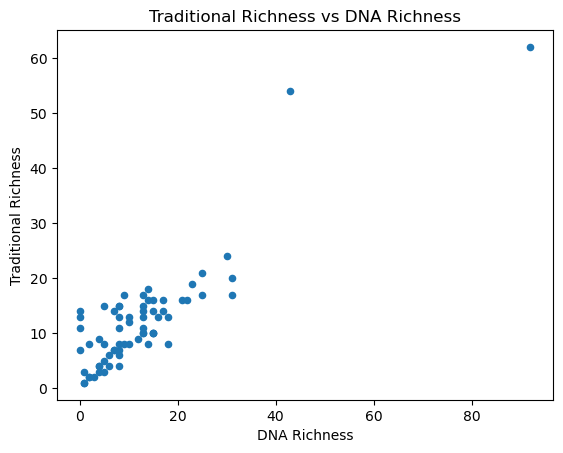

In [13]:
df.plot(x = 'dna_richness', y = 'trad_richness', kind = 'scatter', title = 'Traditional Richness vs DNA Richness', xlabel = 'DNA Richness', ylabel = 'Traditional Richness')


> **Q1:** Does there appear to be a relationship between the two variables? Describe the direction, form, and approximate strength.

Yes, there appears to be a medium positive linear correlation between DNA richness and traditional richness. 

<!-- END QUESTION -->

---
## Step 2: Fit the Regression 

Use `numpy` and the formula below to manually calculate β₁ and β₀. Store your coefficients in the `beta_1` and `beta_0` variables. Then, create a scatter plot of `trad_richness` and `dna_richness` (likely similar to the plot you created above!). Add the fitted line to the scatter plot, and the equation of the line as a legend item. 

$$\hat{\beta}_1 = \frac{\sum(x_i - \bar{x})(y_i - \bar{y})}{\sum(x_i - \bar{x})^2} \qquad \hat{\beta}_0 = \bar{y} - \hat{\beta}_1\bar{x}$$

β₁     = 0.6519
β₀     = 4.0013


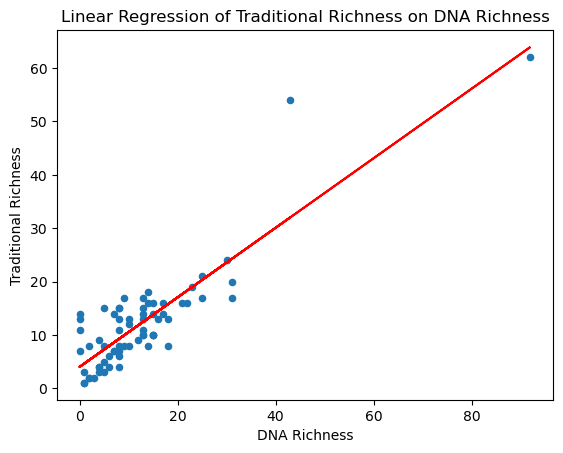

In [31]:

beta_1 = np.corrcoef(df['dna_richness'], df['trad_richness'])[0, 1] * (df['trad_richness'].std() / df['dna_richness'].std())
beta_0 = np.mean(df['trad_richness']) - beta_1 * np.mean(df['dna_richness'])

print(f"\u03b2\u2081     = {beta_1:.4f}")
print(f"\u03b2\u2080     = {beta_0:.4f}")


df.plot(x = 'dna_richness', y = 'trad_richness', kind = 'scatter')
x = np.array(df['dna_richness'])
y_pred = beta_0 + beta_1 * x
plt.plot(x, y_pred, color='red')
plt.xlabel('DNA Richness')
plt.ylabel('Traditional Richness')
plt.title('Linear Regression of Traditional Richness on DNA Richness')
plt.show()

In [32]:
grader.check("q2")

q2 results: All test cases passed!

<!-- BEGIN QUESTION -->

---
## Step 3: Interpret the Coefficients



> **Q2:** Interpret the slope in plain language. Include units.





> **Q3:** Interpret the intercept. Is it ecologically meaningful?



The slope is positive linear when there is 0 DNA richness there is still 4 units of Traditional richness which is ecologically meaningful because it suggests that even in the absence of DNA richness, there is a baseline level of traditional richness. For every unit increase in DNA richness, there is an increase of 0.65 units in Traditional richness.


<!-- END QUESTION -->

---
## Step 4: Compute Standard Errors

Use `numpy` and the formula below to manually calculate the standard errors. Store the RSE in a variable called `RSE`, the standard error of β₁ in a variable called `SE_beta_1`, and the standard error of β₀ in a variable called `SE_beta_0`. 

$$SS_{xx} = \sum(x_i - \bar{x})^2$$

$$RSE = \sqrt{\frac{RSS}{n-2}}$$

$$SE(\hat{\beta}_1) = \frac{RSE}{SS_{xx}}$$

$$SE(\hat{\beta}_0) = RSE \sqrt{\frac{1}{n} + \frac{\bar{x}^2}{SS_{xx}}}$$

In [33]:

RSE       = np.sqrt(np.sum((df['trad_richness'] - (beta_0 + beta_1 * df['dna_richness']))**2) / (len(df) - 2))
SE_beta_1 = np.sqrt(RSE**2 / np.sum((df['dna_richness'] - df['dna_richness'].mean())**2))
SE_beta_0 = RSE * np.sqrt(1/len(df) + (df['dna_richness'].mean()**2 / np.sum((df['dna_richness'] - df['dna_richness'].mean())**2)))

print(f"RSE      = {RSE:.4f}  (species)")
print(f"SE(\u03b2\u2081)   = {SE_beta_1:.4f}")
print(f"SE(\u03b2\u2080)   = {SE_beta_0:.4f}")

RSE      = 4.7441  (species)
SE(β₁)   = 0.0446
SE(β₀)   = 0.7974


In [34]:
grader.check("q4")

q4 results: All test cases passed!

---
## Step 5: Manually Calculate 95% Confidence Intervals for $\beta_0$ and $\beta_1$

Using the formula below, manually calculate an approximate 95% confidence interval for β₀ and β₁. 

$$95\% \text{ CI} \simeq \hat{\beta}_i \pm 2 \times SE(\hat{\beta})$$

In [28]:
CI_beta_1_lower = beta_1 - 2 * SE_beta_1
CI_beta_1_upper = beta_1 + 2 * SE_beta_1

CI_beta_0_lower = beta_0 - 2 * SE_beta_0
CI_beta_0_upper = beta_0 + 2 * SE_beta_0

print(f"\n95% CI for \u03b2\u2081 (slope):  ({CI_beta_1_lower:.4f},  {CI_beta_1_upper:.4f})")
print(f"95% CI for \u03b2\u2080 (intercept): ({CI_beta_0_lower:.4f},  {CI_beta_0_upper:.4f})")


95% CI for β₁ (slope):  (0.5627,  0.7411)
95% CI for β₀ (intercept): (2.4064,  5.5962)


In [29]:
grader.check("q5")

q5 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q4:** Interpret the 95% CI for the slope in plain language.

We are 95% confident that the true slope of the relationship between DNA richness and traditional richness lies within .56 and .74. This indicates a statistically significant relationship between the two variables.

<!-- END QUESTION -->

---
## Step 6: Assess Model Accuracy — R²

Manually calculate the R² using the formula below. Store your answer in the `R2` variable. 

$$R^2 = 1 - \frac{RSS}{TSS} \qquad TSS = \sum_{i=1}^{n}(y_i - \bar{y})^2$$

In [35]:
R2     = np.corrcoef(df['dna_richness'], df['trad_richness'])[0, 1] ** 2

print(f"R\u00b2     = {R2:.4f}")

R²     = 0.7640


In [36]:
grader.check("q7")

q7 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q5:** Interpret the R² in the context of this problem.

Our R2 of .76 means that 76% of the variance in traditional richness can be explained by the variance in DNA richness.

<!-- END QUESTION -->

---
## Step 7: Verify with `sklearn`

Let's confirm our manual OLS results using `sklearn`'s `LinearRegression`.

> **Note:** `sklearn` expects a 2D feature matrix, so we need to reshape `X` from
> shape `(n,)` to `(n, 1)` using `.reshape(-1, 1)` before fitting.

1. **Fit the model** — `LinearRegression().fit(X_2d, Y)` finds the same OLS solution as
   our manual β₁ and β₀ formulas.
2. **Extract coefficients** — `.coef_[0]` is the slope, `.intercept_` is the intercept.
3. **Compute R²** — `r2_score(Y, y_pred)` uses the $R^2 = 1 - RSS/TSS$. formula, where `y_pred = your_fitted_model.predict(X_2d)`
   
4. Create a table that compares the manually calculated and `LinearRegression()` generated slope, intercept, and R². 

If your manual calculations are correct, all three values should match `sklearn`'s output
to at least four decimal places. Any discrepancy beyond floating-point rounding
indicates a bug in your manual formulas.

In [56]:
fitted = LinearRegression().fit(df[['dna_richness']], df['trad_richness'])

sk_slope     = fitted.coef_[0]
sk_intercept = fitted.intercept_
sk_r2        = r2_score(df['trad_richness'], fitted.predict(df[['dna_richness']]))

print(f"sklearn  slope     = {sk_slope:.4f},  manual slope     = {beta_1:.4f}")
print(f"sklearn  intercept = {sk_intercept:.4f},  manual intercept = {beta_0:.4f}")
print(f"sklearn  R\u00b2        = {sk_r2:.4f},  manual R\u00b2        = {R2:.4f}")

sklearn  slope     = 0.6519,  manual slope     = 0.6519
sklearn  intercept = 4.0013,  manual intercept = 4.0013
sklearn  R²        = 0.7640,  manual R²        = 0.7640


In [57]:
grader.check("q9")

q9 results: All test cases passed!

---
## Step 8: Verify with `statsmodels` 

`sklearn` is optimized for **prediction**: it fits models efficiently and scores them, but it deliberately leaves out statistical inference (standard errors, p-values, confidence intervals).

`statsmodels` is designed for **inference**: it fits the same OLS model but reports the full regression table — coefficients, standard errors, t-statistics, p-values, and confidence intervals — matching what you'd see in a statistics textbook.


1. Import `statsmodels.api as sm`.
2. Add a constant (intercept) column to `X` using `sm.add_constant()`.
3. Fit the model with `sm.OLS(Y, X_sm).fit()` and call `.summary()` to display the full regression table.
4. Extract the slope, intercept, and R² from the fitted model and compare them to your numpy and sklearn results. Store the statsmodels slope in `sm_slope`, the intercept in `sm_intercept`, and R² in `sm_r2`.

If all three methods are correct, the coefficients and R² should match to at least four decimal places.

In [74]:
import statsmodels.api as sm

X = sm.add_constant(df['dna_richness'])
model = sm.OLS(df['trad_richness'], X).fit()

sm_intercept = model.params[0]
sm_slope     = model.params[1]
sm_r2        = model.rsquared

model.summary()

<positron-console-cell-74>:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
<positron-console-cell-74>:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          trad_richness   R-squared:                       0.764
Model:                            OLS   Adj. R-squared:                  0.760
Method:                 Least Squares   F-statistic:                     213.7
Date:                Sat, 11 Apr 2026   Prob (F-statistic):           2.25e-22
Time:                        16:28:21   Log-Likelihood:                -201.34
No. Observations:                  68   AIC:                             406.7
Df Residuals:                      66   BIC:                             411.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            4.0013      0.797      5.018      0.000       2.409       5.593
dna_richness     0.6519      0.045     14.618      0.000       0.563       0.741
==============================================================================
Omnibus:                       39.645   Durbin-Watson:                   1.912
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              119.718
Skew:                           1.786   Prob(JB):                     1.01e-26
Kurtosis:                       8.430   Cond. No.                         24.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [75]:
grader.check("q10")

q10 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q6:** Look at the **p-values** for the slope (`dna_richness`) and intercept (`const`) in the statsmodels summary.
>
> - What does the p-value for the **slope** tell you? Is the relationship between eDNA richness and traditional richness statistically significant? How do you know?
<!-- END QUESTION -->


The p-value is 0 so we reject the null hypothesis that there is no relationship between DNA richness and Traditional richness therefore the relationship is statistically significant. Also the R^2 of .76 indicates a strong model fit. 



---

**Run the cell below to receive credit for all auto graded questions.**

In [77]:
grader.check_all()

q10 results: All test cases passed!

q2 results: All test cases passed!

q4 results: All test cases passed!

q5 results: All test cases passed!

q7 results: All test cases passed!

q9 results: All test cases passed!